# **FDA ASSIGNMENT 3 - KEYWORD CO-OCCURENCE NETWORK ANALYSIS**

# **NAME: RIAN RENOLD DBRITTO**

# **NUID: 002026598**

### **MOUNTING THE DRIVE WITH UPLOADED DATA FILES**

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pandas as pd

file_path = '/content/drive/MyDrive/FDA_Assignment/savedrecs_2020.xls'
file_path = '/content/drive/MyDrive/FDA_Assignment/savedrecs_2021.xls'
file_path = '/content/drive/MyDrive/FDA_Assignment/savedrecs_2022.xls'
file_path = '/content/drive/MyDrive/FDA_Assignment/savedrecs_2023.xls'
file_path = '/content/drive/MyDrive/FDA_Assignment/savedrecs_2024.xls'

df = pd.read_excel(file_path)
df.head()


,Publication Type,Authors,Book Authors,Book Editors,Book Group Authors,Author Full Names,Book Author Full Names,Group Authors,Article Title,Source Title,...,Web of Science Index,Research Areas,IDS Number,Pubmed Id,Open Access Designations,Highly Cited Status,Hot Paper Status,Date of Export,UT (Unique WOS ID),Web of Science Record
0,C,"Weisz, JD; He, J; Muller, M; Hoefer, G; Miles,...",NaN,NaN,ACM,"Weisz, Justin D.; He, Jessica; Muller, Michael...",NaN,NaN,Design Principles for Generative AI Applications,PROCEEDINGS OF THE 2024 CHI CONFERENCE ON HUMA...,...,Conference Proceedings Citation Index - Scienc...,Computer Science,BX2GA,NaN,"hybrid, Green Submitted",NaN,NaN,2025-04-04,WOS:001259864901023,0
1,C,"Tang, J; Dong, YX; Vazirgiannis, M",NaN,NaN,ASSOC COMPUTING MACHINERY,"Tang, Jie; Dong, Yuxiao; Vazirgiannis, Michalis",NaN,NaN,Generative AI Day,PROCEEDINGS OF THE 30TH ACM SIGKDD CONFERENCE ...,...,Conference Proceedings Citation Index - Scienc...,Computer Science,BX7OY,NaN,NaN,NaN,NaN,2025-04-04,WOS:001324524206058,0
2,J,"Cox, A",NaN,NaN,NaN,"Cox, Andrew",NaN,NaN,"Algorithmic Literacy, AI Literacy and Responsi...",JOURNAL OF WEB LIBRARIANSHIP,...,Emerging Sources Citation Index (ESCI),Information Science & Library Science,O9G9S,NaN,hybrid,NaN,NaN,2025-04-04,WOS:001329496000001,0
3,C,"Reddy, GP; Sinha, S; Park, SH",NaN,NaN,IEEE,"Reddy, G. Pradeep; Sinha, Shrutika; Park, Soo-...",NaN,NaN,Generative AI for the Maritime Environments,2024 FIFTEENTH INTERNATIONAL CONFERENCE ON UBI...,...,Conference Proceedings Citation Index - Scienc...,Engineering; Telecommunications,BX6BC,NaN,NaN,NaN,NaN,2025-04-04,WOS:001307336600141,0
4,J,"Immorlica, N; Lucier, B; Slivkins, A",NaN,NaN,NaN,"Immorlica, Nicole; Lucier, Brendan; Slivkins, ...",NaN,NaN,Generative AI as Economic Agents,ACM SIGECOM EXCHANGES,...,Emerging Sources Citation Index (ESCI),Computer Science,L3I6C,NaN,Green Submitted,NaN,NaN,2025-04-04,WOS:001349692800005,0


### **EXTRACTING REQUIRED DATA FROM OUR FILES**

In [34]:
import pandas as pd

file1 = pd.read_excel('savedrecs_2020.xls')
file2 = pd.read_excel('savedrecs_2021.xls')
file3 = pd.read_excel('savedrecs_2022.xls')
file4 = pd.read_excel('savedrecs_2023.xls')
file5 = pd.read_excel('savedrecs_2024.xls')

author_keywords1 = file1['Author Keywords']
author_keywords2 = file2['Author Keywords']
author_keywords3 = file3['Author Keywords']
author_keywords4 = file4['Author Keywords']
author_keywords5 = file5['Author Keywords']



In [9]:
author_keywords1 = author_keywords1.dropna()
author_keywords2 = author_keywords2.dropna()
author_keywords3 = author_keywords3.dropna()
author_keywords4 = author_keywords4.dropna()
author_keywords5 = author_keywords5.dropna()

In [10]:
author_keywords3

,Author Keywords
0,Generative AI; Design; Bias; Uncertainty
1,generative AI; software engineering tooling; e...
2,visual programming environment; generative con...
3,Generative modelling; artificial intelligence;...
4,Generative Design; Digital Manufacturing; Topo...
...,...
493,free energy principle; active inference; varia...
494,Remote sensing; Geology; Feature extraction; T...
496,Law; Annotations; Data integrity; Machine lear...
497,2D materials; coatings; graphene; hexagonal bo...


### **Performing a fresh reinstallation to resolve missing or corrupted components**

In [11]:
!pip install --force-reinstall python-louvain

  Using cached python_louvain-0.16-py3-none-any.whl
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4
  Attempting uninstall: networkx
    Found existing installation: networkx 3.4.2
    Uninstalling networkx-3.4.2:
      Successfully uninstalled networkx-3.4.2
  Attempting uninstall: python-louvain
    Found existing installation: python-louvain 0.16
    Uninstalling python-louvain-0.16:
      Successfully uninstalled python-louvain-0.16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the 

### **Function to create a co-occurrence network with adjustable threshold parameters for edge control, including labeled node centrality and edge weights.**

In [52]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
import community
import community.community_louvain as community_louvain
import numpy as np

def create_keyword_network(keyword_series, threshold=3, top_nodes=50, top_labels=20, seed=42):
    """Process keywords and create a network with visualization parameters."""
    # Cleaning and processing keywords
    keyword_series = keyword_series.astype(str).str.lower()
    keyword_lists = keyword_series.str.split(';').apply(lambda x: [kw.strip() for kw in x if kw.strip()])

    # Creating co-occurrence matrix
    co_occurrences = {}
    for keywords in keyword_lists:
        for pair in combinations(set(keywords), 2):
            sorted_pair = tuple(sorted(pair))
            co_occurrences[sorted_pair] = co_occurrences.get(sorted_pair, 0) + 1

    # Filtering edges by threshold
    filtered_edges = {pair: weight for pair, weight in co_occurrences.items() if weight >= threshold}

    # Building network
    G_filtered = nx.Graph()
    for (kw1, kw2), weight in filtered_edges.items():
        G_filtered.add_edge(kw1, kw2, weight=weight)

    # Calculating centrality and create subgraph
    centrality = nx.degree_centrality(G_filtered)
    top_keywords = sorted(centrality, key=centrality.get, reverse=True)[:top_nodes]
    G_top = G_filtered.subgraph(top_keywords)

    # Community detection
    partition = community_louvain.best_partition(G_top)
    unique_clusters = list(set(partition.values()))
    color_map = {cluster: plt.cm.jet(i / len(unique_clusters)) for i, cluster in enumerate(unique_clusters)}
    node_colors = [color_map[partition[node]] for node in G_top.nodes()]

    # Visualizing parameters
    pos = nx.spring_layout(G_top, seed=seed, k=0.2)
    node_sizes = [centrality[node] * 2000 for node in G_top.nodes()]
    edge_weights = [edata['weight'] for _, _, edata in G_top.edges(data=True)]
    edge_labels = {(kw1, kw2): weight for kw1, kw2, weight in G_top.edges(data="weight")}
    central_nodes = {n: n for n, _ in sorted(G_top.degree(), key=lambda x: x[1], reverse=True)[:top_labels]}

    return {
        'graph': G_top,
        'pos': pos,
        'node_sizes': node_sizes,
        'node_colors': node_colors,
        'edge_weights': edge_weights,
        'edge_labels': edge_labels,
        'central_nodes': central_nodes
    }



### **Function to visualize the co-occurrence network.**

In [13]:
def plot_network(network_data, figsize=(15, 10), title="Keyword Co-Occurrence Network (Top Research Themes) with Weights"):
    """Plot the network using precomputed parameters."""
    plt.figure(figsize=figsize)

    # Unpack network data
    G = network_data['graph']
    pos = network_data['pos']
    node_sizes = network_data['node_sizes']
    node_colors = network_data['node_colors']
    edge_weights = network_data['edge_weights']
    edge_labels = network_data['edge_labels']
    central_nodes = network_data['central_nodes']

    # Draw components
    nx.draw_networkx_edges(
        G, pos, alpha=0.4,
        width=np.array(edge_weights) / max(edge_weights) * 5,
        edge_color="purple"
    )
    nx.draw_networkx_nodes(
        G, pos, node_size=node_sizes,
        node_color=node_colors, alpha=0.9,
        edgecolors="black"
    )
    nx.draw_networkx_labels(
        G, pos, labels=central_nodes,
        font_size=12, font_weight="bold"
    )
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels,
        font_size=8, font_color="red"
    )

    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()

2020

### **A visual representation of the co-occurrence network based on 2020 data.**

In [14]:
network_data1 = create_keyword_network(
    keyword_series=author_keywords1,
    threshold=4,
    top_nodes=50,
    top_labels=20,
    seed=42
)

**Calculation of Degree**

In [15]:
node_degrees_2020 = {node: network_data1['graph'].degree(node) for node in network_data1['graph'].nodes()}
node_degrees_sorted_2020 = sorted(node_degrees_2020.items(), key=lambda x: x[1], reverse=True)

node_degrees_sorted_2020


[('deep learning', 7),
 ('generative adversarial networks', 6),
 ('training', 3),
 ('gallium nitride', 3),
 ('generative models', 2),
 ('machine learning', 2),
 ('generators', 2),
 ('neural networks', 1),
 ('variational autoencoders', 1),
 ('image generation', 1),
 ('generative adversarial network', 1),
 ('artificial intelligence', 1)]

**Average Strength V/S Degree**

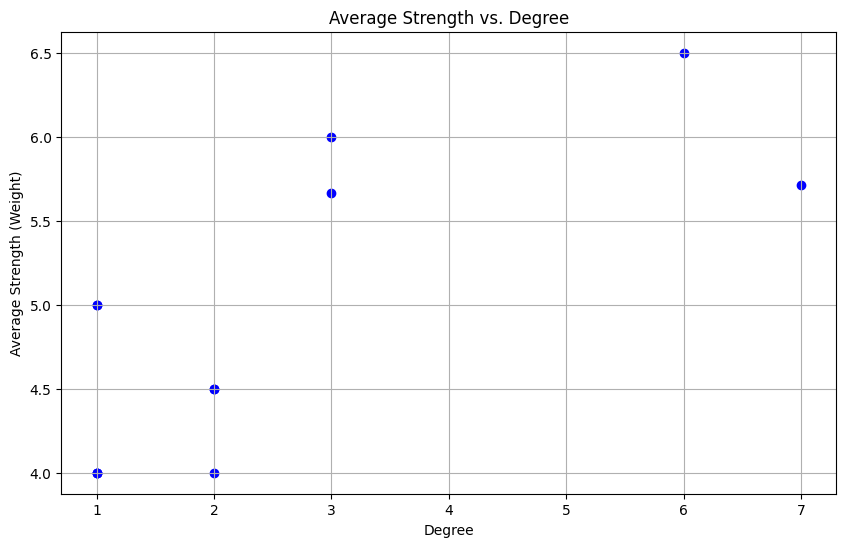

In [18]:
G1 = network_data1['graph']
average_strength = {node: 0 for node in G1.nodes()}
for node in G1.nodes():
    total_weight = sum([attr['weight'] for _, _, attr in G1.edges(node, data=True)])
    average_strength[node] = total_weight / G1.degree(node)

degrees = [G1.degree(node) for node in G1.nodes()]
average_strengths = [average_strength[node] for node in G1.nodes()]

plt.figure(figsize=(10, 6))
plt.scatter(degrees, average_strengths, color='blue')
plt.title("Average Strength vs. Degree")
plt.xlabel("Degree")
plt.ylabel("Average Strength (Weight)")
plt.grid(True)
plt.show()

**Calculation of Node Strength**

In [19]:
node_strengths_2020 = {node: sum(G1[node][neighbor]['weight'] for neighbor in G1[node]) for node in G1.nodes()}

filtered_node_strengths_2020 = {node: strength for node, strength in node_strengths_2020.items() if strength > 1}

node_strengths_sorted_2020 = sorted(filtered_node_strengths_2020.items(), key=lambda x: x[1], reverse=True)
pd.DataFrame(node_strengths_sorted_2020, columns=['Node', 'Strength'])

,Node,Strength
0,deep learning,40
1,generative adversarial networks,39
2,gallium nitride,18
3,training,17
4,generative models,9
5,machine learning,9
6,generators,8
7,generative adversarial network,5
8,artificial intelligence,5
9,neural networks,4


### **A visual representation of the co-occurrence network based on 2021 data**

In [36]:
network_data2 = create_keyword_network(
    keyword_series=author_keywords2,
    threshold=4,
    top_nodes=50,
    top_labels=20,
    seed=42
)

**Calculation of Degree**

In [37]:
node_degrees_2021 = {node: network_data2['graph'].degree(node) for node in network_data2['graph'].nodes()}
node_degrees_sorted_2021 = sorted(node_degrees_2021.items(), key=lambda x: x[1], reverse=True)

node_degrees_sorted_2021

[('generative adversarial networks', 9),
 ('training', 7),
 ('deep learning', 6),
 ('generators', 4),
 ('task analysis', 4),
 ('gallium nitride', 4),
 ('generative adversarial network', 3),
 ('machine learning', 3),
 ('artificial intelligence', 2),
 ('data models', 2),
 ('feature extraction', 2),
 ('image reconstruction', 2),
 ('generative models', 1),
 ('ai', 1),
 ('data augmentation', 1),
 ('image-to-image translation', 1)]

**Average Strength V/S Degree**

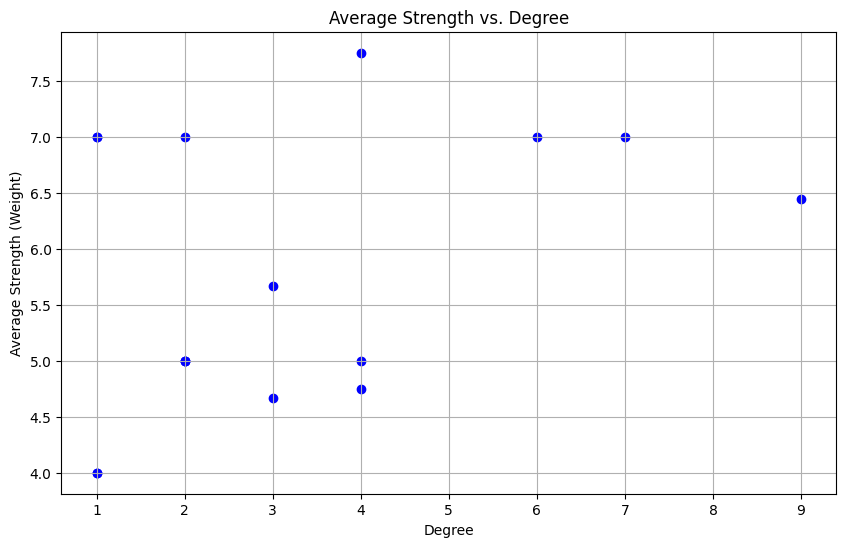

In [38]:
G1 = network_data2['graph']  # Get the graph from the network_data1 dictionary
average_strength = {node: 0 for node in G1.nodes()}
for node in G1.nodes():
    total_weight = sum([attr['weight'] for _, _, attr in G1.edges(node, data=True)])
    average_strength[node] = total_weight / G1.degree(node)  # Use G.degree to get the degree

# Extract degree and average strength for each node
degrees = [G1.degree(node) for node in G1.nodes()]  # Use G.degree to get the degree
average_strengths = [average_strength[node] for node in G1.nodes()]

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(degrees, average_strengths, color='blue')
plt.title("Average Strength vs. Degree")
plt.xlabel("Degree")
plt.ylabel("Average Strength (Weight)")
plt.grid(True)
plt.show()

**Calculation of Node Strength**

In [39]:
node_strengths_2021 = {node: sum(G1[node][neighbor]['weight'] for neighbor in G1[node]) for node in G1.nodes()}

filtered_node_strengths_2021 = {node: strength for node, strength in node_strengths_2021.items() if strength > 1}

node_strengths_sorted_2021 = sorted(filtered_node_strengths_2021.items(), key=lambda x: x[1], reverse=True)
pd.DataFrame(node_strengths_sorted_2021, columns=['Node', 'Strength'])

,Node,Strength
0,generative adversarial networks,58
1,training,49
2,deep learning,42
3,generators,31
4,gallium nitride,20
5,task analysis,19
6,generative adversarial network,17
7,machine learning,14
8,artificial intelligence,14
9,data models,10


### **A visual representation of the co-occurrence network based on 2022 data**

In [40]:
network_data3 = create_keyword_network(
    keyword_series=author_keywords3,
    threshold=4,
    top_nodes=50,
    top_labels=20,
    seed=42
)

**Calculation of Degree**

In [41]:
node_degrees_2022 = {node: network_data3['graph'].degree(node) for node in network_data3['graph'].nodes()}
node_degrees_sorted_2022 = sorted(node_degrees_2022.items(), key=lambda x: x[1], reverse=True)

node_degrees_sorted_2022

[('generative adversarial networks', 12),
 ('deep learning', 9),
 ('machine learning', 4),
 ('generative adversarial network (gan)', 4),
 ('training', 4),
 ('artificial intelligence', 3),
 ('generators', 2),
 ('ai', 1),
 ('image-to-image translation', 1),
 ('generative adversarial network', 1),
 ('computer vision', 1),
 ('task analysis', 1),
 ('gan', 1),
 ('convolutional neural network (cnn)', 1),
 ('data augmentation', 1),
 ('feature extraction', 1),
 ('synthetic data generation', 1),
 ('data models', 1),
 ('generative models', 1)]

**Average Strength V/S Degree**

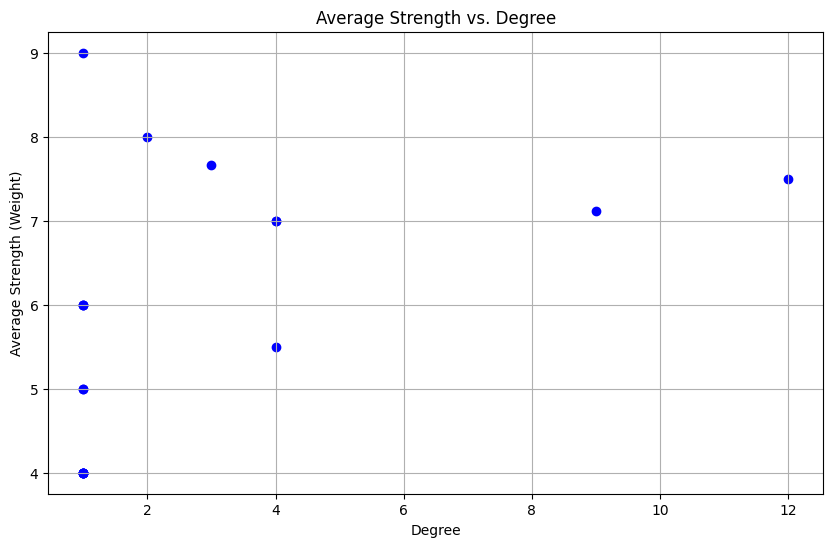

In [42]:
G1 = network_data3['graph']  # Get the graph from the network_data1 dictionary
average_strength = {node: 0 for node in G1.nodes()}
for node in G1.nodes():
    total_weight = sum([attr['weight'] for _, _, attr in G1.edges(node, data=True)])
    average_strength[node] = total_weight / G1.degree(node)  # Use G.degree to get the degree

# Extract degree and average strength for each node
degrees = [G1.degree(node) for node in G1.nodes()]  # Use G.degree to get the degree
average_strengths = [average_strength[node] for node in G1.nodes()]

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(degrees, average_strengths, color='blue')
plt.title("Average Strength vs. Degree")
plt.xlabel("Degree")
plt.ylabel("Average Strength (Weight)")
plt.grid(True)
plt.show()

**Calculation of Node Strength**

In [43]:
node_strengths_2022 = {node: sum(G1[node][neighbor]['weight'] for neighbor in G1[node]) for node in G1.nodes()}

filtered_node_strengths_2022 = {node: strength for node, strength in node_strengths_2022.items() if strength > 1}

node_strengths_sorted_2022 = sorted(filtered_node_strengths_2022.items(), key=lambda x: x[1], reverse=True)
pd.DataFrame(node_strengths_sorted_2022, columns=['Node', 'Strength'])

,Node,Strength
0,generative adversarial networks,90
1,deep learning,64
2,machine learning,28
3,training,28
4,artificial intelligence,23
5,generative adversarial network (gan),22
6,generators,16
7,generative adversarial network,9
8,task analysis,6
9,data augmentation,6


### **A visual representation of the co-occurrence network based on 2023 data**

In [44]:
network_data4 = create_keyword_network(
    keyword_series=author_keywords4,
    threshold=5,
    top_nodes=50,
    top_labels=20,
    seed=42
)

**Calculation of Degree**

In [45]:
node_degrees_2023 = {node: network_data4['graph'].degree(node) for node in network_data4['graph'].nodes()}
node_degrees_sorted_2023 = sorted(node_degrees_2023.items(), key=lambda x: x[1], reverse=True)

node_degrees_sorted_2023

[('artificial intelligence', 16),
 ('generative ai', 14),
 ('chatgpt', 13),
 ('ai', 3),
 ('large language models', 3),
 ('large language model', 3),
 ('gpt-4', 2),
 ('gpt', 2),
 ('deep learning', 2),
 ('machine learning', 2),
 ('generative artificial intelligence', 2),
 ('ethics', 2),
 ('human-ai interaction', 1),
 ('education', 1),
 ('llm', 1),
 ('gpt-3', 1),
 ('ai ethics', 1),
 ('assessment', 1),
 ('computer vision', 1),
 ('chatbots', 1),
 ('bard', 1),
 ('academic integrity', 1),
 ('openai', 1),
 ('generative pre-trained transformer', 1),
 ('natural language processing', 1),
 ('medical education', 1),
 ('generative', 1),
 ('generative adversarial networks', 1)]

**Average Strength V/S Degree**

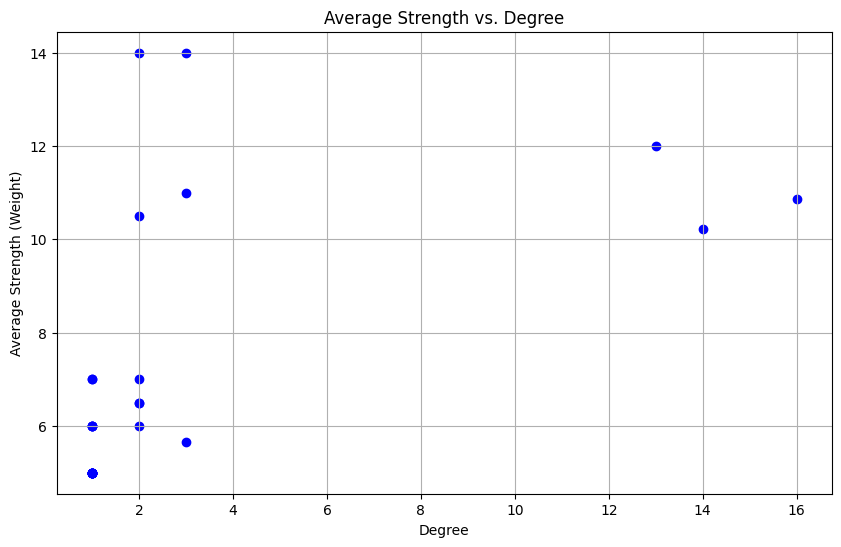

In [46]:
G1 = network_data4['graph']  # Get the graph from the network_data1 dictionary
average_strength = {node: 0 for node in G1.nodes()}
for node in G1.nodes():
    total_weight = sum([attr['weight'] for _, _, attr in G1.edges(node, data=True)])
    average_strength[node] = total_weight / G1.degree(node)  # Use G.degree to get the degree

# Extract degree and average strength for each node
degrees = [G1.degree(node) for node in G1.nodes()]  # Use G.degree to get the degree
average_strengths = [average_strength[node] for node in G1.nodes()]

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(degrees, average_strengths, color='blue')
plt.title("Average Strength vs. Degree")
plt.xlabel("Degree")
plt.ylabel("Average Strength (Weight)")
plt.grid(True)
plt.show()

**Calculation of Node Strength**

In [47]:
node_strengths_2023 = {node: sum(G1[node][neighbor]['weight'] for neighbor in G1[node]) for node in G1.nodes()}

filtered_node_strengths_2023 = {node: strength for node, strength in node_strengths_2023.items() if strength > 1}

node_strengths_sorted_2023 = sorted(filtered_node_strengths_2023.items(), key=lambda x: x[1], reverse=True)
pd.DataFrame(node_strengths_sorted_2023, columns=['Node', 'Strength'])

,Node,Strength
0,artificial intelligence,174
1,chatgpt,156
2,generative ai,143
3,large language models,42
4,ai,33
5,machine learning,28
6,generative artificial intelligence,21
7,large language model,17
8,ethics,14
9,gpt-4,13


### **A visual representation of the co-occurrence network based on 2024 data**

In [48]:
network_data5 = create_keyword_network(
    keyword_series=author_keywords5,
    threshold=5,
    top_nodes=50,
    top_labels=20,
    seed=42
)

**Calculation of Degree**

In [49]:
node_degrees_2024 = {node: network_data5['graph'].degree(node) for node in network_data5['graph'].nodes()}
node_degrees_sorted_2024 = sorted(node_degrees_2024.items(), key=lambda x: x[1], reverse=True)

node_degrees_sorted_2024

[('generative ai', 34),
 ('chatgpt', 7),
 ('artificial intelligence', 6),
 ('large language models', 4),
 ('ai', 3),
 ('education', 3),
 ('higher education', 3),
 ('prompt engineering', 2),
 ('foundation models', 1),
 ('large language model', 1),
 ('large language models (llms)', 1),
 ('deep learning', 1),
 ('creativity', 1),
 ('explainable ai', 1),
 ('machine learning', 1),
 ('visualization', 1),
 ('ethics', 1),
 ('chatbot', 1),
 ('learning', 1),
 ('ai ethics', 1),
 ('chatbots', 1),
 ('software engineering', 1),
 ('llms', 1),
 ('bias', 1),
 ('human-ai interaction', 1),
 ('data models', 1),
 ('natural language processing', 1),
 ('artificial intelligence (ai)', 1),
 ('generative artificial intelligence', 1),
 ('genai', 1),
 ('assessment', 1),
 ('llm', 1),
 ('user experience', 1),
 ('training', 1),
 ('aied', 1),
 ('gpt', 1)]

**Average Strength V/S Degree**

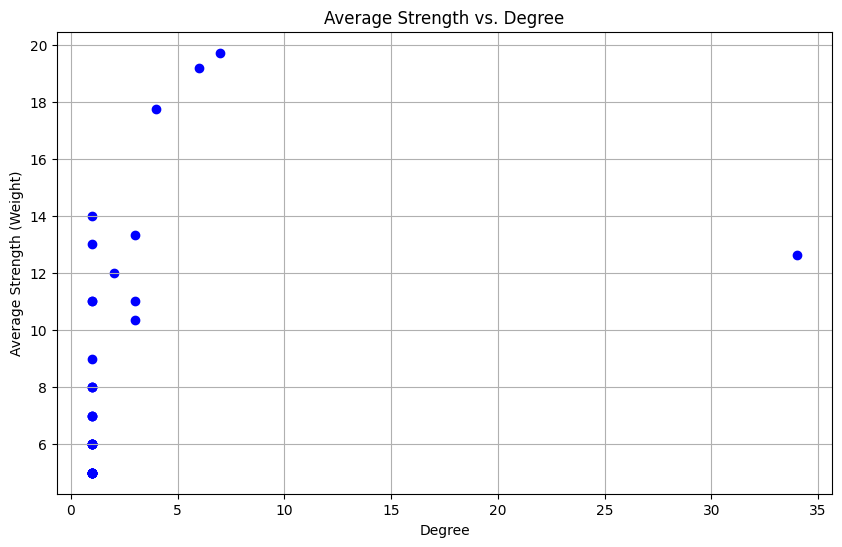

In [50]:
G1 = network_data5['graph']  # Get the graph from the network_data1 dictionary
average_strength = {node: 0 for node in G1.nodes()}
for node in G1.nodes():
    total_weight = sum([attr['weight'] for _, _, attr in G1.edges(node, data=True)])
    average_strength[node] = total_weight / G1.degree(node)  # Use G.degree to get the degree

# Extract degree and average strength for each node
degrees = [G1.degree(node) for node in G1.nodes()]  # Use G.degree to get the degree
average_strengths = [average_strength[node] for node in G1.nodes()]

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(degrees, average_strengths, color='blue')
plt.title("Average Strength vs. Degree")
plt.xlabel("Degree")
plt.ylabel("Average Strength (Weight)")
plt.grid(True)
plt.show()

**Calculation of Node Strength**

In [51]:
node_strengths_2024 = {node: sum(G1[node][neighbor]['weight'] for neighbor in G1[node]) for node in G1.nodes()}

filtered_node_strengths_2024 = {node: strength for node, strength in node_strengths_2024.items() if strength > 1}

node_strengths_sorted_2024 = sorted(filtered_node_strengths_2024.items(), key=lambda x: x[1], reverse=True)
pd.DataFrame(node_strengths_sorted_2024, columns=['Node', 'Strength'])

,Node,Strength
0,generative ai,429
1,chatgpt,138
2,artificial intelligence,115
3,large language models,71
4,education,40
5,ai,33
6,higher education,31
7,prompt engineering,24
8,llms,14
9,chatbots,13
